<a href="https://colab.research.google.com/github/qaiserfatmi/Dengue/blob/main/Dengue_ML_Analysis_New.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Analysis for Dengue from following published Paper**

Iqbal NT, Ahmed K, Khalid A, Imtiaz
K, Ali QM, Munir T, et al. (2025) Clinical
characteristics and serotype association of
dengue and dengue like illness in Pakistan.
PLoS Negl Trop Dis 19(5): e0012978. https://
doi.org/10.1371/journal.pntd.0012978

**Step 1 — Install and import required packages**

In [3]:
!pip install -q xgboost openpyxl mlxtend shap umap-learn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.metrics import silhouette_score

from xgboost import XGBClassifier, XGBRegressor

import shap
import warnings
warnings.filterwarnings("ignore")

**Step 2 — Upload the Excel file**

In [5]:
# Use if you want to Browse File from computer

#from google.colab import files
#uploaded = files.upload()

In [6]:
# Use if you want to directly Read the Excel file from Google colab, after uploading in content folder.

url = "https://journals.plos.org/plosntds/article/file?type=supplementary&id=10.1371/journal.pntd.0012978.s006"
df = pd.read_excel(url)
df.head()

# df = pd.read_excel("/content/journal.pntd.0012978.s006.xlsx")


,N#,Year,Aim,UWARN Sample ID,Inpatient/ Outpatient,Days of Illness,Age,Gender,Clinician I Diagnosis,Clinician II Diagnosis,...,Diarrhea,Heavy menstrual bleed,Blood in stool,Blood in urine,cough,Gum bleeding,Rash,Platelet transfusion,eGFR,Days of Hospitalization
0,0,2.0,1.0,B1-D01-21028-EDT,Outpatient,6.0,27.0,Female,Zika virus infection,Dengue without Warning Signs,...,No,No,No,No,No,No,No,No,No,0.0
1,1,2.0,1.0,B1-D01-11001-EDT,Inpatient,9.0,44.0,Female,Dengue fever,Dengue with warning signs,...,No,Yes,No,No,No,No,No,No,>60,4.0
2,2,2.0,1.0,B1-D01-11002-EDT,Inpatient,7.0,46.0,Female,Dengue fever,Dengue without Warning Signs,...,No,No,No,No,No,No,No,No,>60,2.0
3,3,2.0,1.0,B1-D01-11003-EDT,Inpatient,4.0,12.0,Female,Dengue fever,Dengue without Warning Signs,...,No,No,No,No,No,No,No,No,No,2.0
4,4,2.0,1.0,B1-D01-21001-EDT,Outpatient,5.0,40.0,Male,Acute Viral fever,Dengue with warning signs,...,No,No,No,No,No,No,No,No,>60,0.0


**Step 3 — Check dataset size, sheets, and columns**

In [7]:
df.shape

(352, 78)

In [8]:
df.head()

,N#,Year,Aim,UWARN Sample ID,Inpatient/ Outpatient,Days of Illness,Age,Gender,Clinician I Diagnosis,Clinician II Diagnosis,...,Diarrhea,Heavy menstrual bleed,Blood in stool,Blood in urine,cough,Gum bleeding,Rash,Platelet transfusion,eGFR,Days of Hospitalization
0,0,2.0,1.0,B1-D01-21028-EDT,Outpatient,6.0,27.0,Female,Zika virus infection,Dengue without Warning Signs,...,No,No,No,No,No,No,No,No,No,0.0
1,1,2.0,1.0,B1-D01-11001-EDT,Inpatient,9.0,44.0,Female,Dengue fever,Dengue with warning signs,...,No,Yes,No,No,No,No,No,No,>60,4.0
2,2,2.0,1.0,B1-D01-11002-EDT,Inpatient,7.0,46.0,Female,Dengue fever,Dengue without Warning Signs,...,No,No,No,No,No,No,No,No,>60,2.0
3,3,2.0,1.0,B1-D01-11003-EDT,Inpatient,4.0,12.0,Female,Dengue fever,Dengue without Warning Signs,...,No,No,No,No,No,No,No,No,No,2.0
4,4,2.0,1.0,B1-D01-21001-EDT,Outpatient,5.0,40.0,Male,Acute Viral fever,Dengue with warning signs,...,No,No,No,No,No,No,No,No,>60,0.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352 entries, 0 to 351
Data columns (total 78 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   N#                                    350 non-null    object        
 1   Year                                  349 non-null    float64       
 2   Aim                                   349 non-null    float64       
 3   UWARN Sample ID                       349 non-null    object        
 4   Inpatient/ Outpatient                 349 non-null    object        
 5   Days of Illness                       318 non-null    float64       
 6   Age                                   349 non-null    float64       
 7   Gender                                349 non-null    object        
 8   Clinician I Diagnosis                 340 non-null    object        
 9   Clinician II Diagnosis                349 non-null    object        
 10  Fi

In [10]:
df.columns.tolist()

['N#',
 'Year ',
 'Aim',
 'UWARN Sample ID',
 'Inpatient/ Outpatient',
 'Days of Illness',
 'Age ',
 'Gender',
 'Clinician I Diagnosis',
 'Clinician II Diagnosis',
 'Final Diagnosis',
 'Sample Collection Date  (DD/MM/YYYY)',
 'Final Dx (Peter)',
 'Peter Diagnosis',
 'NS-1 antigen',
 'IgM Antibody',
 'DENV Dx Results',
 'RNaseP PCR',
 'RNaseP Cq Value',
 'DENV PCR ',
 'DENV Cq Value',
 'ZIKV PCR ',
 'ZIKV Cq Value',
 'DENV Serotype',
 'DV1',
 'DV2',
 'DV3',
 'DV4',
 ' Fever or chills ',
 'Days of Fever',
 'Fever or chills onset date',
 'Currently symptomatic?',
 'Fever or chills resolution date',
 'Weight Kg',
 'Systolic Blood Pressure',
 'Diastolic Blood Pressure',
 'Pulse',
 'Temperature (c)',
 'Respiratory rate',
 'Pulse oxygen %',
 'Hemotocrit (%)',
 'WBC_count (10^9/L)',
 'Lymph_count (%)',
 'Neut_count  (%)',
 'Hemoglobin (g/dl)',
 'Platelet        (10^9/L)',
 'Thrombocytopenia Grade',
 'NLR',
 'ALT (IU/L)',
 'AST (IU/L)',
 'BUN  (mg/dl)',
 'Creatinine     (mg/dl)',
 'BACTERIA',
 

**Step 4 — Clean column names**

In [11]:
# Store original names for comparison
original_columns = df.columns.tolist()

# Clean column names
df.columns = (
    df.columns
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", "_", regex=True)
    .str.replace(r"[^\w]", "_", regex=True)
    .str.replace(r"_+", "_", regex=True)
    .str.strip("_")
)

# Check whether cleaning created duplicate names
duplicates = df.columns[df.columns.duplicated()].tolist()

print("Cleaned columns:")
print(df.columns.tolist())

print("\nDuplicate columns:")
print(duplicates)

Cleaned columns:
['n', 'year', 'aim', 'uwarn_sample_id', 'inpatient_outpatient', 'days_of_illness', 'age', 'gender', 'clinician_i_diagnosis', 'clinician_ii_diagnosis', 'final_diagnosis', 'sample_collection_date_dd_mm_yyyy', 'final_dx_peter', 'peter_diagnosis', 'ns_1_antigen', 'igm_antibody', 'denv_dx_results', 'rnasep_pcr', 'rnasep_cq_value', 'denv_pcr', 'denv_cq_value', 'zikv_pcr', 'zikv_cq_value', 'denv_serotype', 'dv1', 'dv2', 'dv3', 'dv4', 'fever_or_chills', 'days_of_fever', 'fever_or_chills_onset_date', 'currently_symptomatic', 'fever_or_chills_resolution_date', 'weight_kg', 'systolic_blood_pressure', 'diastolic_blood_pressure', 'pulse', 'temperature_c', 'respiratory_rate', 'pulse_oxygen', 'hemotocrit', 'wbc_count_10_9_l', 'lymph_count', 'neut_count', 'hemoglobin_g_dl', 'platelet_10_9_l', 'thrombocytopenia_grade', 'nlr', 'alt_iu_l', 'ast_iu_l', 'bun_mg_dl', 'creatinine_mg_dl', 'bacteria', 'alt_class', 'ast_class', 'population_density', 'humidity', 'hospitalization', 'hypertension'

**Step 5 — Inspect important diagnostic columns**

In [12]:
for col in df.columns:
    if any(keyword in col.lower() for keyword in [
        "pcr", "ns", "igm", "igg", "diagnosis",
        "serotype", "hospital", "severity", "dengue"
    ]):
        print("\nCOLUMN:", col)
        print(df[col].value_counts(dropna=False).head(20))
        print("-" * 70)


COLUMN: clinician_i_diagnosis
clinician_i_diagnosis
Dengue fever                                                            247
Fever                                                                    30
NaN                                                                      12
Viral Fever                                                               6
Viral fever                                                               5
Suspected Dengue fever                                                    4
Dengue like illness                                                       3
Enteric fever                                                             2
URTI                                                                      2
Upper respiratory tract infection                                         2
Suspected Dengue                                                          2
Acute Gastroenteritis                                                     2
Suspected EBV reactivation         

**Step 6 — Select the correct DENV PCR column**

In [13]:
pcr_col = "denv_pcr"

df[pcr_col].value_counts(dropna=False)

,count
denv_pcr,
Positive,203
Negative,80
NaN,69


**Step 7 — Convert DENV PCR result into binary target**

In [14]:
def convert_pcr_result(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().lower()

    if x in ["positive", "pos", "+", "1", "1.0", "yes", "detected"]:
        return 1

    if x in ["negative", "neg", "-", "0", "0.0", "no", "not detected"]:
        return 0

    return np.nan

df["PCR_positive"] = df[pcr_col].apply(convert_pcr_result)

df["PCR_positive"].value_counts(dropna=False)

,count
PCR_positive,
1.0,203
0.0,80
NaN,69


**Step 8 — Keep only PCR-tested patients**

In [15]:
df_pcr = df.dropna(subset=["PCR_positive"]).copy()
df_pcr["PCR_positive"] = df_pcr["PCR_positive"].astype(int)

df_pcr["PCR_positive"].value_counts()

,count
PCR_positive,
1,203
0,80


**Step 9 — Remove diagnostic leakage columns**

In [16]:
# This is the most important scientific correction. When predicting PCR positivity, do not include variables that directly reveal diagnosis.

leakage_keywords = [
    "pcr", "cq", "ct", "serotype", "denv",
    "diagnosis", "dx", "ns_1", "ns1", "igm", "igg",
    "final", "positive", "negative", "rnasep", "zikv",
    "dv1", "dv2", "dv3", "dv4"
]

leakage_cols = [
    col for col in df_pcr.columns
    if any(keyword in col.lower() for keyword in leakage_keywords)
]

leakage_cols

['clinician_i_diagnosis',
 'clinician_ii_diagnosis',
 'final_diagnosis',
 'sample_collection_date_dd_mm_yyyy',
 'final_dx_peter',
 'peter_diagnosis',
 'ns_1_antigen',
 'igm_antibody',
 'denv_dx_results',
 'rnasep_pcr',
 'rnasep_cq_value',
 'denv_pcr',
 'denv_cq_value',
 'zikv_pcr',
 'zikv_cq_value',
 'denv_serotype',
 'dv1',
 'dv2',
 'dv3',
 'dv4',
 'bacteria',
 'PCR_positive']

In [17]:
# Create features and target:

X = df_pcr.drop(columns=leakage_cols, errors="ignore")
y = df_pcr["PCR_positive"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (283, 57)
y shape: (283,)
PCR_positive
1    203
0     80
Name: count, dtype: int64


**Step 10 — Remove ID, date, sample, and administrative columns**

In [18]:
drop_keywords = ["id", "name", "mr", "file", "date", "sample", "n"]

drop_cols = [
    col for col in X.columns
    if any(keyword in col.lower() for keyword in drop_keywords)
]

X = X.drop(columns=drop_cols, errors="ignore")

print("Final X shape:", X.shape)

Final X shape: (283, 26)


**Step 11 — Separate numeric and categorical features**

In [19]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)

Numeric features: 12
['year', 'aim', 'age', 'days_of_fever', 'systolic_blood_pressure', 'diastolic_blood_pressure', 'pulse', 'temperature_c', 'respiratory_rate', 'hemotocrit', 'platelet_10_9_l', 'ast_iu_l']

Categorical features: 14
['fever_or_chills', 'weight_kg', 'alt_iu_l', 'alt_class', 'ast_class', 'diabetes', 'cardiovascular_disease', 'fever', 'headache', 'bodyache', 'diarrhea', 'cough', 'rash', 'egfr']


**Step 12 — Fix mixed categorical data types**

In [20]:
# Encoders require their input argument must be uniformly strings or numbers

X_fixed = X.copy()

for col in categorical_features:
    X_fixed[col] = X_fixed[col].astype(str)

print("X_fixed shape:", X_fixed.shape)

X_fixed shape: (283, 26)


**Step 13 — Build preprocessing pipeline**

In [21]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    sparse_threshold=0
)

**Step 14 — Train-test split**

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_fixed,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\ny_train distribution:")
print(y_train.value_counts())

print("\ny_test distribution:")
print(y_test.value_counts())

X_train: (212, 26)
X_test: (71, 26)

y_train distribution:
PCR_positive
1    152
0     60
Name: count, dtype: int64

y_test distribution:
PCR_positive
1    51
0    20
Name: count, dtype: int64


**Step 15 — Define ML models**

In [23]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ),

    "SVM": SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ),

    "kNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Naive Bayes": GaussianNB(),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
}

**Step 16 — Train and evaluate models**

In [24]:
results = []

for name, model in models.items():
    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    try:
        y_prob = clf.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    except Exception:
        auc = np.nan

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1_score": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": auc
    })

results_df = pd.DataFrame(results).sort_values("ROC_AUC", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1_score,ROC_AUC
2,Random Forest,0.746479,0.753846,0.960784,0.844828,0.724510
0,Logistic Regression,0.732394,0.847826,0.764706,0.804124,0.721569
4,kNN,0.718310,0.771930,0.862745,0.814815,0.666667
3,SVM,0.676056,0.804348,0.725490,0.762887,0.652941
6,XGBoost,0.704225,0.777778,0.823529,0.800000,0.632353
5,Naive Bayes,0.478873,0.769231,0.392157,0.519481,0.608824
1,Decision Tree,0.591549,0.729167,0.686275,0.707071,0.518137


**Figure 1. Bar plot of model performance**

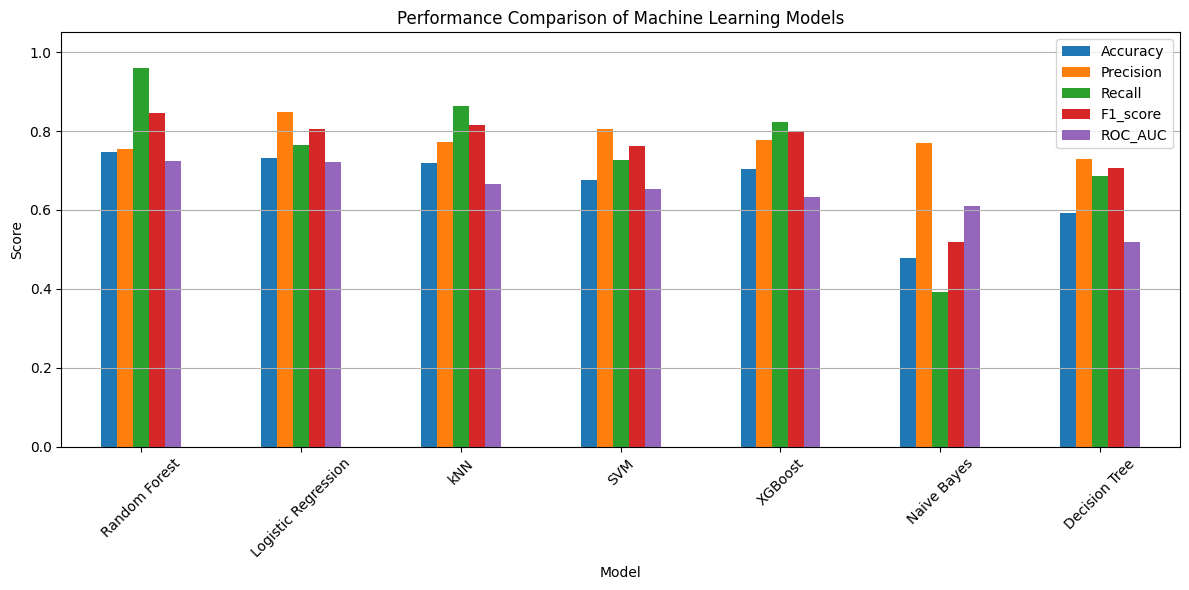

In [25]:
results_df_plot = results_df.set_index("Model")
results_df_plot[["Accuracy","Precision","Recall","F1_score","ROC_AUC"]].plot(
    kind="bar",
    figsize=(12,6)
)
plt.ylabel("Score")
plt.title("Performance Comparison of Machine Learning Models")
plt.xticks(rotation=45)
plt.ylim(0,1.05)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

**Figure 2. ROC Curves**

In [26]:
# Modify the training loop slightly to save probabilities.

roc_results = {}
results = []
for name, model in models.items():
    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    try:
        y_prob = clf.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test,y_prob)
        roc_results[name] = y_prob
    except:
        auc = np.nan
    results.append({
        "Model":name,
        "Accuracy":accuracy_score(y_test,y_pred),
        "Precision":precision_score(y_test,y_pred),
        "Recall":recall_score(y_test,y_pred),
        "F1_score":f1_score(y_test,y_pred),
        "ROC_AUC":auc
    })

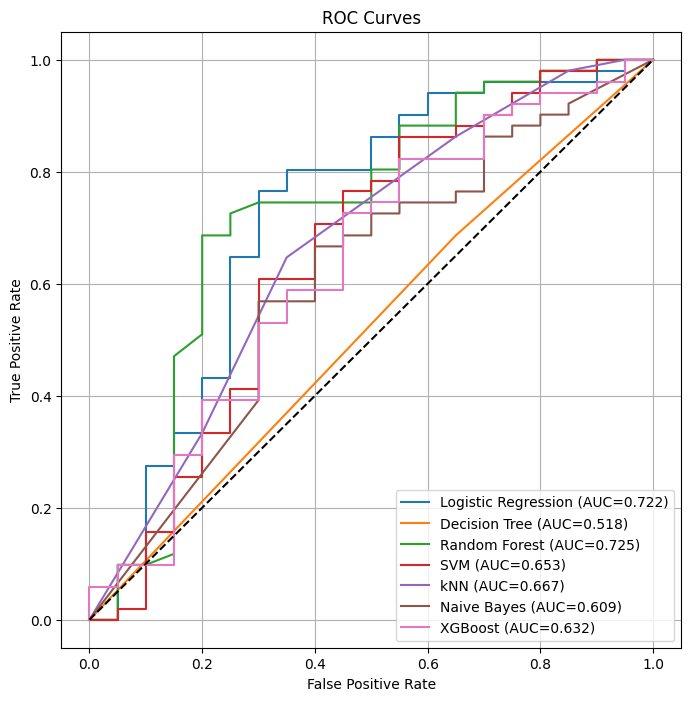

In [27]:
# plot ROC curves

from sklearn.metrics import roc_curve
plt.figure(figsize=(8,8))
for name,y_prob in roc_results.items():
    fpr,tpr,_ = roc_curve(y_test,y_prob)
    auc = roc_auc_score(y_test,y_prob)
    plt.plot(fpr,tpr,label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid()
plt.show()

**Figure 3. Confusion Matrix**

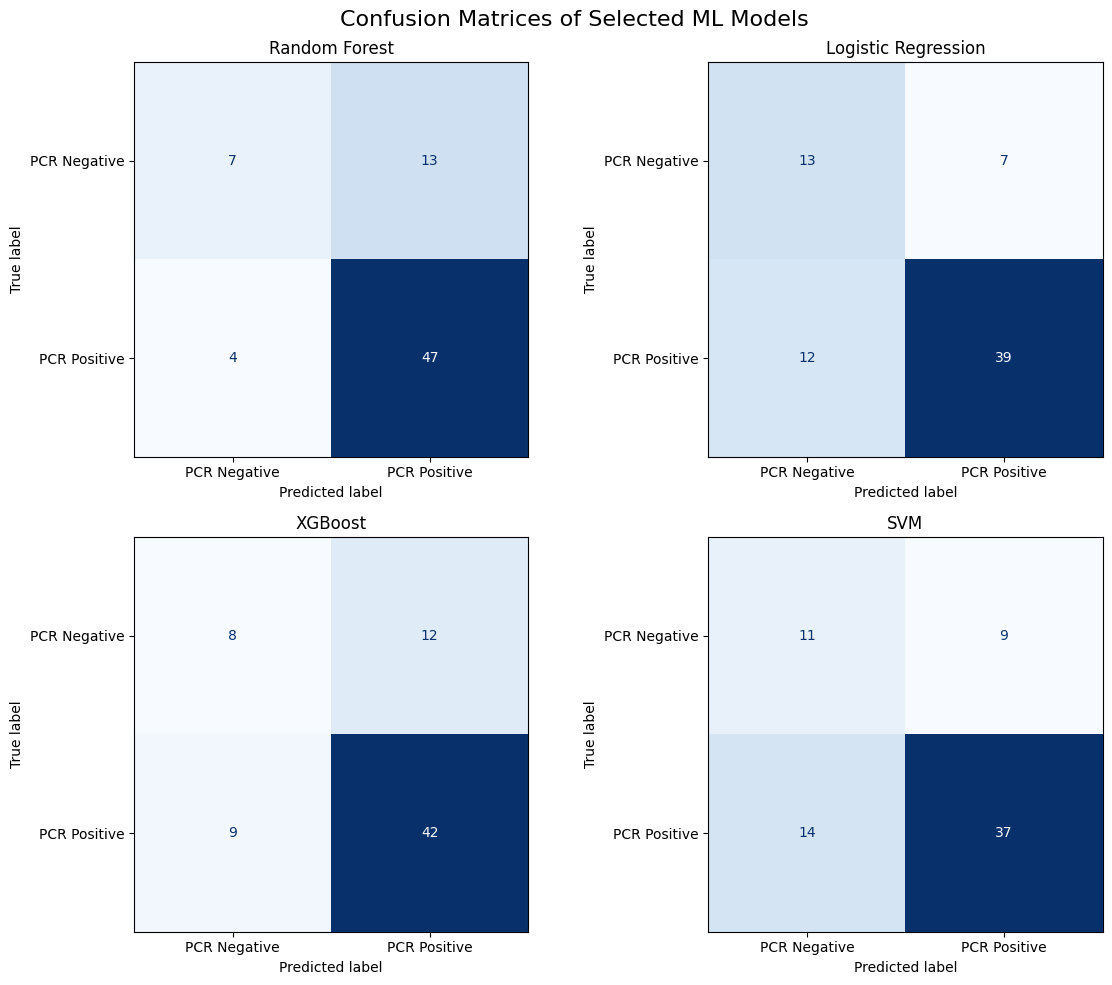

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models_cm = {
    "Random Forest": RandomForestClassifier(random_state=42),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ),

    "SVM": SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    )
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (name, model) in zip(axes, models_cm.items()):

    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    clf.fit(X_train, y_train)

    ConfusionMatrixDisplay.from_estimator(
        clf,
        X_test,
        y_test,
        display_labels=["PCR Negative", "PCR Positive"],
        cmap="Blues",
        ax=ax,
        colorbar=False
    )

    ax.set_title(name)

plt.suptitle("Confusion Matrices of Selected ML Models", fontsize=16)
plt.tight_layout()
plt.show()

**Figure 4. Precision-Recall Curves**

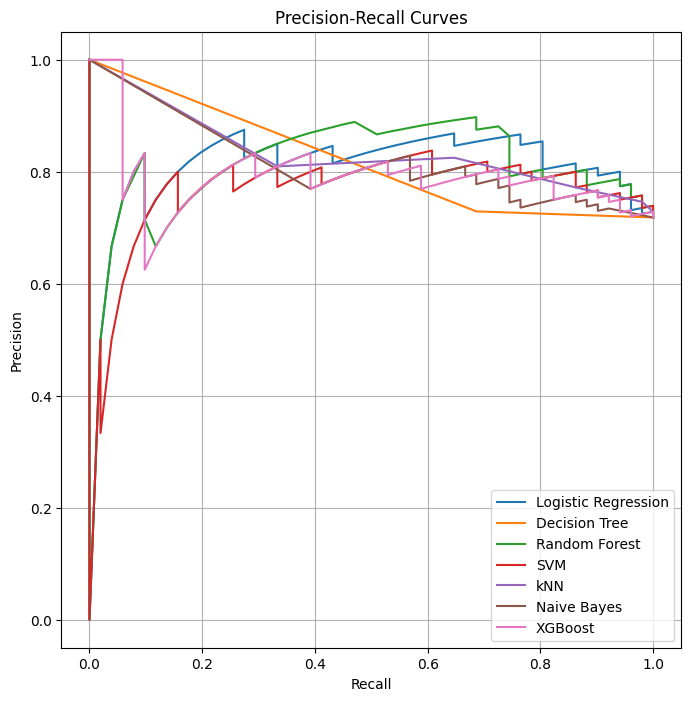

In [34]:
from sklearn.metrics import precision_recall_curve
plt.figure(figsize=(8,8))
for name,y_prob in roc_results.items():
    precision,recall,_ = precision_recall_curve(
        y_test,
        y_prob
    )
    plt.plot(recall,precision,label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid()
plt.show()

**Figure 5. Heatmap of Metrics**

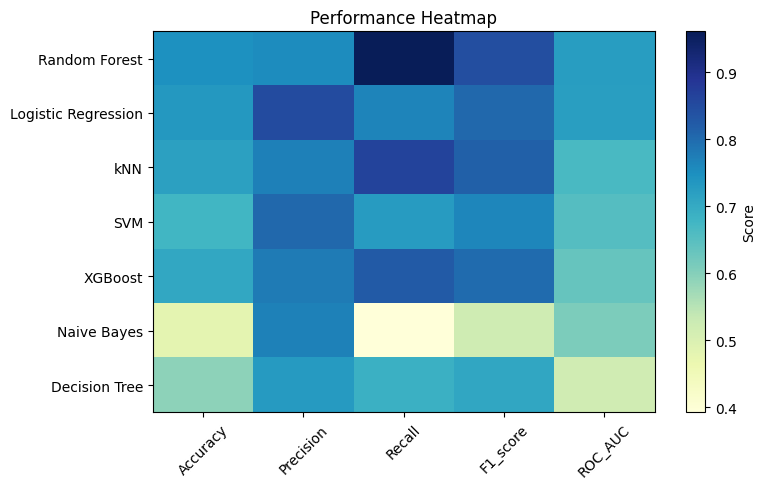

In [35]:
import matplotlib.pyplot as plt
metrics = results_df.set_index("Model")
plt.figure(figsize=(8,5))
plt.imshow(metrics,cmap="YlGnBu",aspect="auto")
plt.colorbar(label="Score")
plt.xticks(range(len(metrics.columns)),metrics.columns,rotation=45)
plt.yticks(range(len(metrics.index)),metrics.index)
plt.title("Performance Heatmap")
plt.tight_layout()
plt.show()

**Figure 6. Feature Importance**


Random Forest


,Feature_cleaned,Feature_original,Importance,SD
12,platelet_10_9_l,Platelet (10^9/L),0.078824,0.036864
25,egfr,eGFR,0.036667,0.023606
4,days_of_fever,Days of Fever,0.023529,0.017543
13,alt_iu_l,ALT (IU/L),0.023162,0.014496
5,weight_kg,Weight Kg,0.021471,0.011185
10,respiratory_rate,Respiratory rate,0.021005,0.010501
11,hemotocrit,Hemotocrit (%),0.015637,0.012314
18,cardiovascular_disease,Cardiovascular disease,0.015074,0.003115
8,pulse,Pulse,0.013456,0.015718
2,age,Age,0.009853,0.008493



Logistic Regression


,Feature_cleaned,Feature_original,Importance,SD
12,platelet_10_9_l,Platelet (10^9/L),0.119265,0.048370
13,alt_iu_l,ALT (IU/L),0.046225,0.014921
9,temperature_c,Temperature (c),0.036569,0.024746
25,egfr,eGFR,0.019363,0.013503
18,cardiovascular_disease,Cardiovascular disease,0.013676,0.012845
5,weight_kg,Weight Kg,0.007598,0.017169
14,ast_iu_l,AST (IU/L),0.007451,0.007385
2,age,Age,0.006716,0.007520
0,year,Year,0.004706,0.011644
15,alt_class,ALT class,0.002696,0.007110



XGBoost


,Feature_cleaned,Feature_original,Importance,SD
12,platelet_10_9_l,Platelet (10^9/L),0.151225,0.059286
25,egfr,eGFR,0.035931,0.019260
9,temperature_c,Temperature (c),0.030098,0.018397
10,respiratory_rate,Respiratory rate,0.016716,0.007508
13,alt_iu_l,ALT (IU/L),0.012255,0.008170
0,year,Year,0.008284,0.003765
5,weight_kg,Weight Kg,0.002353,0.002042
15,alt_class,ALT class,0.002304,0.001589
2,age,Age,0.002255,0.015545
7,diastolic_blood_pressure,Diastolic Blood Pressure,0.000735,0.012404



SVM


,Feature_cleaned,Feature_original,Importance,SD
12,platelet_10_9_l,Platelet (10^9/L),0.145735,0.057101
9,temperature_c,Temperature (c),0.039314,0.022740
25,egfr,eGFR,0.017990,0.015969
13,alt_iu_l,ALT (IU/L),0.010392,0.005418
14,ast_iu_l,AST (IU/L),0.008824,0.010245
2,age,Age,0.007206,0.006920
0,year,Year,0.005931,0.007032
3,fever_or_chills,Fever or chills,0.002402,0.005023
18,cardiovascular_disease,Cardiovascular disease,0.001324,0.003566
23,cough,cough,0.000784,0.004413


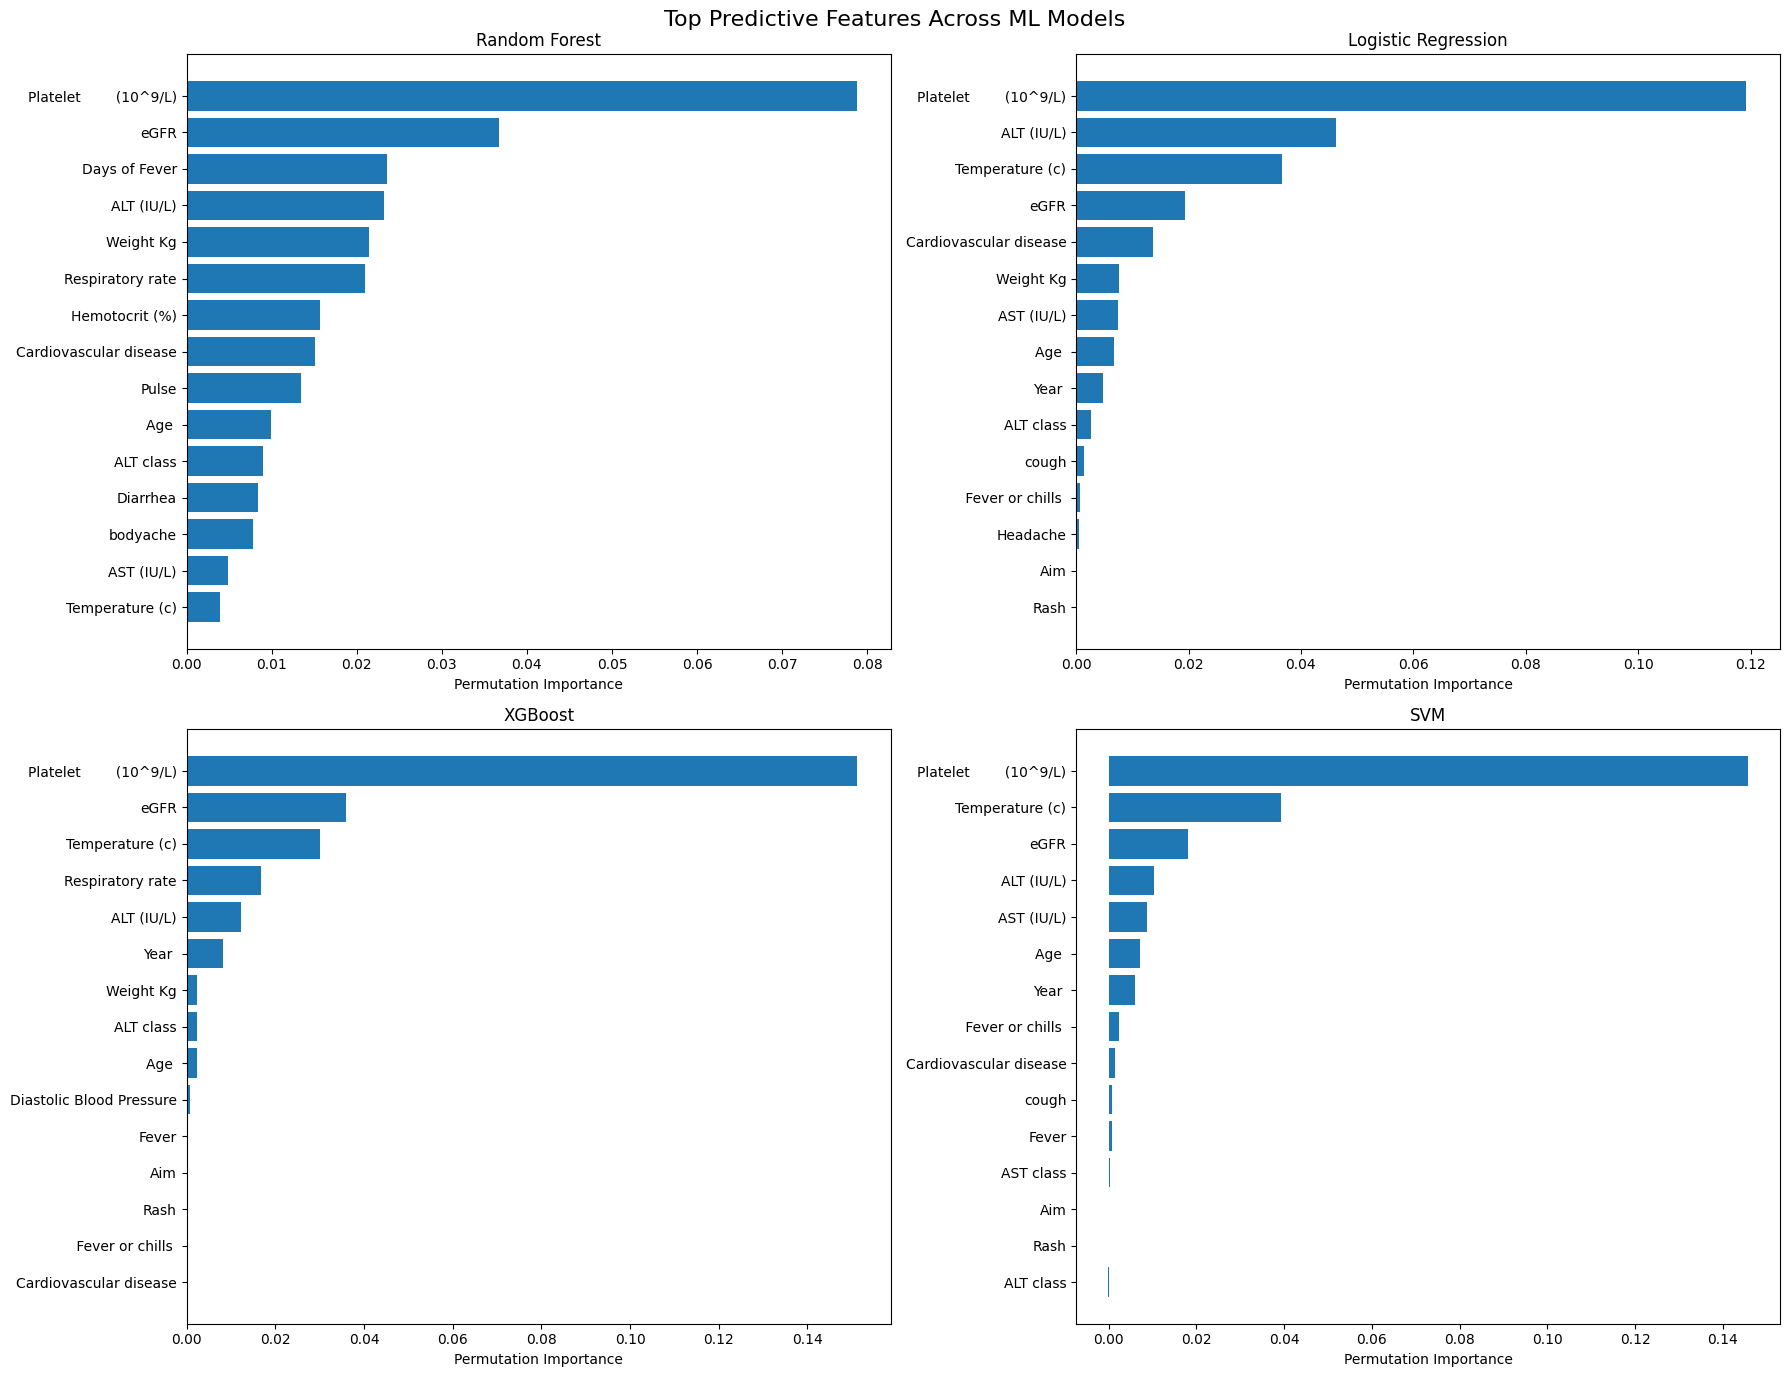

In [39]:
from sklearn.inspection import permutation_importance

# Step 1: Create mapping from cleaned column names (back to original Excel column names)

cleaned_columns_from_original = (
    pd.Series(original_columns)
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", "_", regex=True)
    .str.replace(r"[^\w]", "_", regex=True)
    .str.replace(r"_+", "_", regex=True)
    .str.strip("_")
    .tolist()
)

clean_to_original = dict(zip(cleaned_columns_from_original, original_columns))

# Step 2: Define selected models

models_importance = {
    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ),

    "SVM": SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    )
}

# Step 3: Calculate permutation importance

importance_tables = {}

for name, model in models_importance.items():

    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    clf.fit(X_train, y_train)

    result = permutation_importance(
        clf,
        X_test,
        y_test,
        scoring="roc_auc",
        n_repeats=20,
        random_state=42
    )

    importance_df = pd.DataFrame({
        "Feature_cleaned": X_test.columns,
        "Feature_original": [
            clean_to_original.get(col, col) for col in X_test.columns
        ],
        "Importance": result.importances_mean,
        "SD": result.importances_std
    }).sort_values("Importance", ascending=False)

    importance_tables[name] = importance_df

    print("\n" + "="*70)
    print(name)
    print("="*70)
    display(importance_df.head(20))

# Step 4: Plot top 15 features for each model in 2 x 2 format

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.ravel()

for ax, (name, importance_df) in zip(axes, importance_tables.items()):

    top = importance_df.head(15).sort_values("Importance")

    ax.barh(
        top["Feature_original"],
        top["Importance"]
    )

    ax.set_title(name)
    ax.set_xlabel("Permutation Importance")

plt.suptitle(
    "Top Predictive Features Across ML Models",
    fontsize=16
)

plt.tight_layout()
plt.show()

**Step 17 — Cross-validation**

In [41]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
cv_results = []
cv_scores = {}          # <-- Store every fold score

for name, model in models.items():
    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    scores = cross_val_score(
        clf,
        X_fixed,
        y,
        cv=cv,
        scoring="roc_auc"
    )
    cv_scores[name] = scores

    cv_results.append({
        "Model": name,
        "Mean_ROC_AUC": scores.mean(),
        "SD_ROC_AUC": scores.std()
    })

cv_results_df = (
    pd.DataFrame(cv_results)
      .sort_values("Mean_ROC_AUC", ascending=False)
)

cv_results_df

,Model,Mean_ROC_AUC,SD_ROC_AUC
2,Random Forest,0.711974,0.080329
0,Logistic Regression,0.700213,0.043547
3,SVM,0.694200,0.065312
6,XGBoost,0.679322,0.098037
4,kNN,0.656555,0.099803
1,Decision Tree,0.593384,0.061861
5,Naive Bayes,0.563853,0.067003


# **Interpretation:**
**The key point is that ROC-AUC tells you how well a model separates the two classes (e.g., PCR positive vs PCR negative). A value of 0.5 means the model is no better than random guessing, while 1.0 means perfect discrimination.**

Five-fold stratified cross-validation demonstrated that the Random Forest classifier achieved the highest mean ROC-AUC (0.712 ± 0.080), indicating the best overall discriminative performance among the evaluated algorithms. Logistic Regression showed comparable predictive ability (0.700 ± 0.044) while exhibiting the lowest variability across folds, suggesting superior robustness and consistency. Support Vector Machine also demonstrated competitive performance (0.694 ± 0.065). In contrast, Decision Tree (0.593 ± 0.062) and Naive Bayes (0.564 ± 0.067) showed limited discriminative ability. These findings suggest that ensemble-based and linear models are more suitable than single-tree or independence-based classifiers for predicting the outcome in this dataset.

## **What does ROC-AUC 0.712 mean?**

On average, the Random Forest model achieved an ROC-AUC of 0.712 across five different train-test splits.

A ROC-AUC of 0.712 can also be interpreted probabilistically:

If you randomly select one PCR-positive patient and one PCR-negative patient, the Random Forest model has about a 71.2% probability of assigning a higher predicted risk to the PCR-positive patient than to the PCR-negative patient.

## **Main conclusion from this result**

The ML analysis supports this statement:

Routine clinical and laboratory features show moderate predictive ability for qRT-PCR-confirmed dengue infection, with Random Forest outperforming XGBoost, logistic regression, SVM, kNN, decision tree, and Naive Bayes models. However, the model performance remains exploratory and should be interpreted as diagnostic-support rather than a replacement for qRT-PCR.

This fits well with the paper, because the article emphasizes that qRT-PCR improved dengue detection and detected cases missed by NS1/IgM screening. The paper reported 203 PCR-positive and 80 PCR-negative cases among 283 PCR-tested patients, and qRT-PCR detected additional dengue cases among rapid-test-negative viral-fever patients.

**Iqbal NT, Ahmed K, Khalid A, Imtiaz K, Ali QM, Munir T, et al. (2025) Clinical
characteristics and serotype association of dengue and dengue like illness in Pakistan. PLoS Negl Trop Dis 19(5): e0012978. https://
doi.org/10.1371/journal.pntd.0012978**


Imp. Note:

The dataset contains about 121 patients, so the differences between:

* 0.712 (Random Forest),
* 0.700 (Logistic Regression), and
* 0.694 (SVM)

are relatively small. Without a formal statistical comparison (e.g., repeated cross-validation with paired tests or another appropriate comparison), you should avoid claiming that Random Forest is significantly better than Logistic Regression. It is more accurate to state that Random Forest achieved the highest mean ROC-AUC, while Logistic Regression exhibited the greatest stability across folds.


**Figure 7. Mean ROC-AUC ± Standard Deviation**

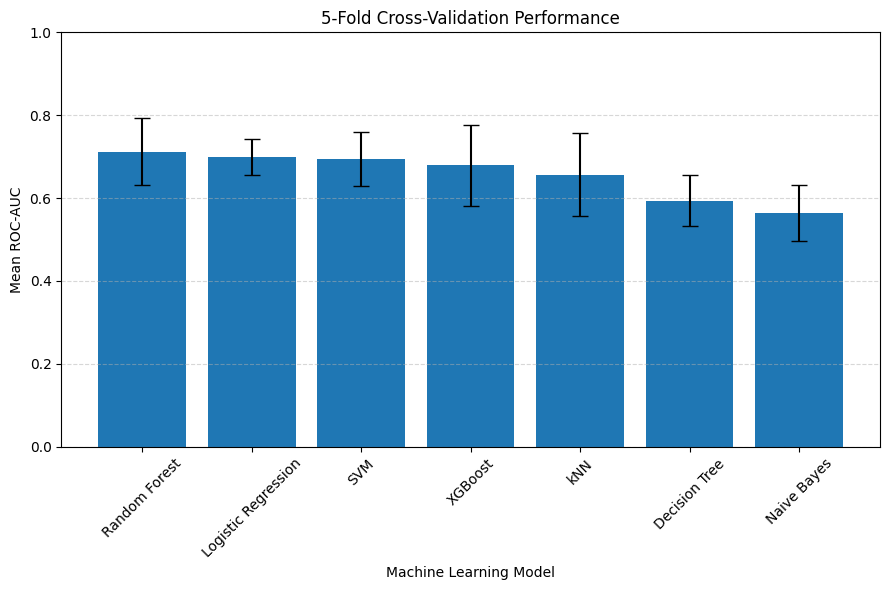

In [42]:
plt.figure(figsize=(9,6))

plt.bar(
    cv_results_df["Model"],
    cv_results_df["Mean_ROC_AUC"],
    yerr=cv_results_df["SD_ROC_AUC"],
    capsize=6
)

plt.ylabel("Mean ROC-AUC")
plt.xlabel("Machine Learning Model")
plt.title("5-Fold Cross-Validation Performance")

plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**Figure 8. ROC-AUC Boxplot Across Folds**

Interpretation:

* Smaller box = more stable model.
* Higher median = better model.
* Smaller whiskers = lower variability.

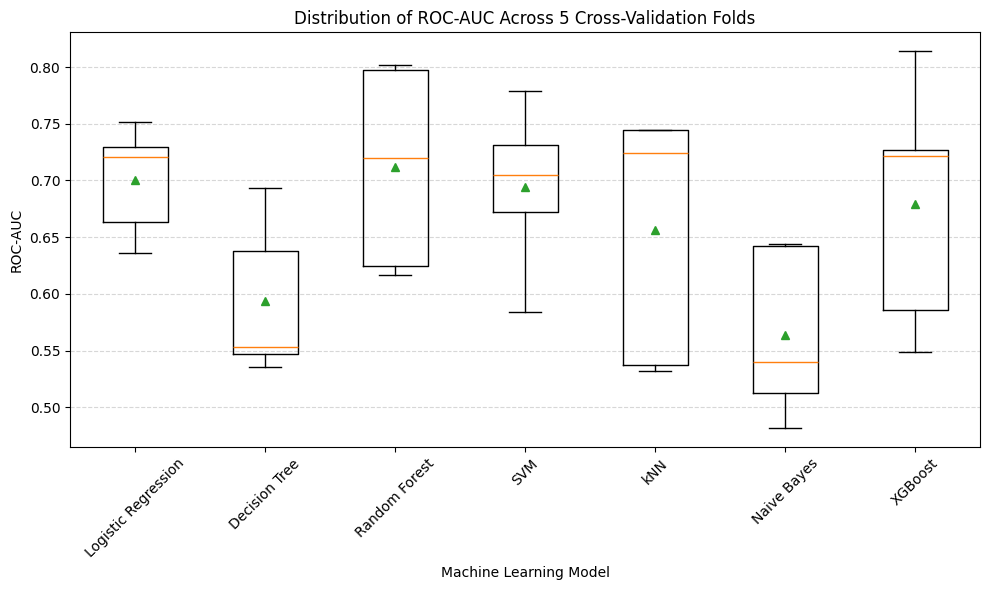

In [43]:
# This shows how stable each model is across the five folds.

plt.figure(figsize=(10,6))
plt.boxplot(
    [cv_scores[m] for m in cv_scores.keys()],
    tick_labels=cv_scores.keys(),
    showmeans=True
)
plt.ylabel("ROC-AUC")
plt.xlabel("Machine Learning Model")
plt.title("Distribution of ROC-AUC Across 5 Cross-Validation Folds")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Figure 9. Model Stability Comparison**

It tells:

* which model has the highest ROC-AUC;
* which model has the smallest standard deviation;
* the trade-off between performance and stability.

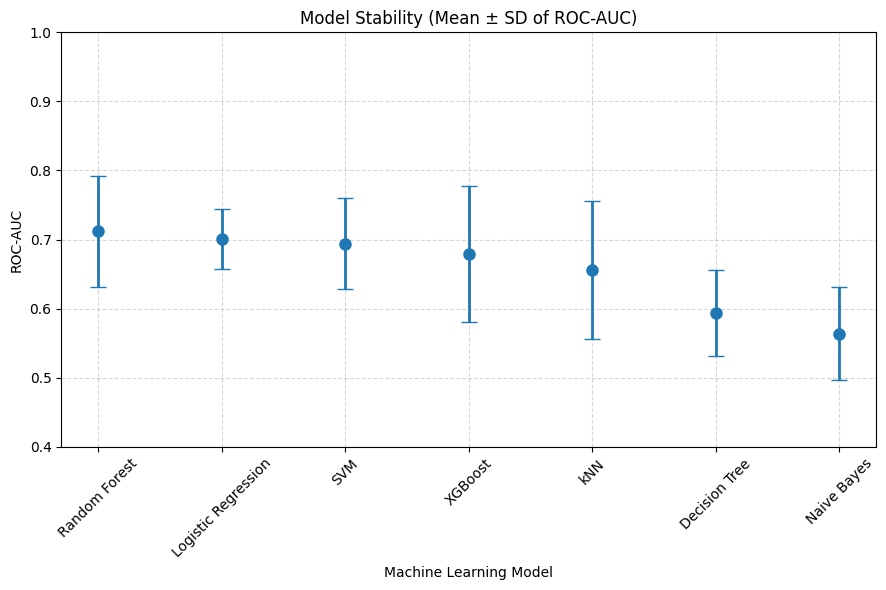

In [44]:
plt.figure(figsize=(9,6))

plt.errorbar(
    cv_results_df["Model"],
    cv_results_df["Mean_ROC_AUC"],
    yerr=cv_results_df["SD_ROC_AUC"],
    fmt="o",
    capsize=6,
    linewidth=2,
    markersize=8
)
plt.ylabel("ROC-AUC")
plt.xlabel("Machine Learning Model")
plt.title("Model Stability (Mean ± SD of ROC-AUC)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.ylim(0.4,1.0)
plt.tight_layout()
plt.show()

**Figure 10. Fold-wise ROC-AUC**

This highlights whether a model performs consistently across folds or has unusually high or low performance in specific folds.

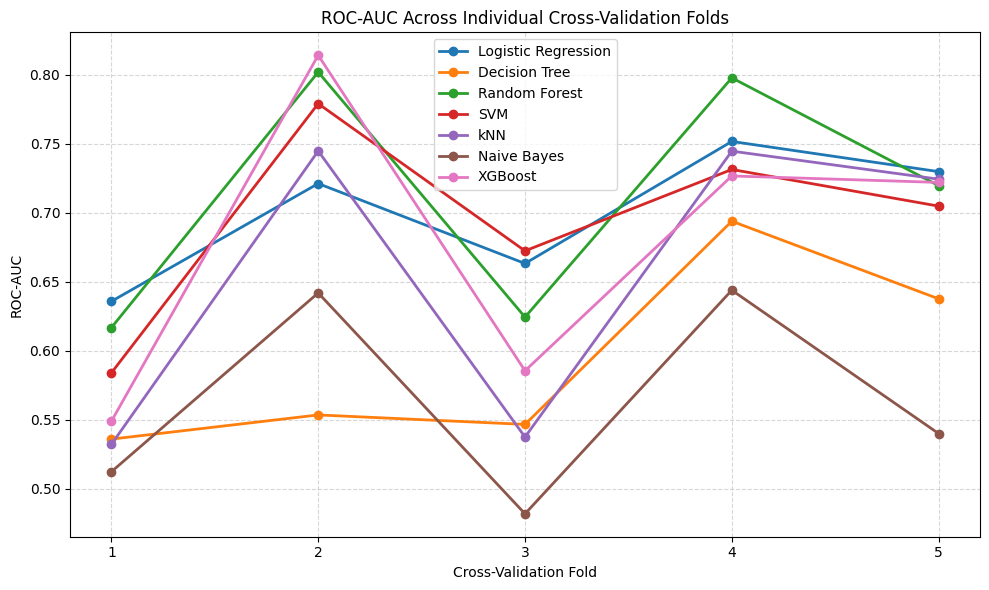

In [45]:
cv_plot = pd.DataFrame(cv_scores)

plt.figure(figsize=(10,6))
for model in cv_plot.columns:
    plt.plot(
        range(1,6),
        cv_plot[model],
        marker="o",
        linewidth=2,
        label=model
    )
plt.xlabel("Cross-Validation Fold")
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC Across Individual Cross-Validation Folds")
plt.xticks(range(1,6))
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

**Figure 11. Ranked Mean ROC-AUC**

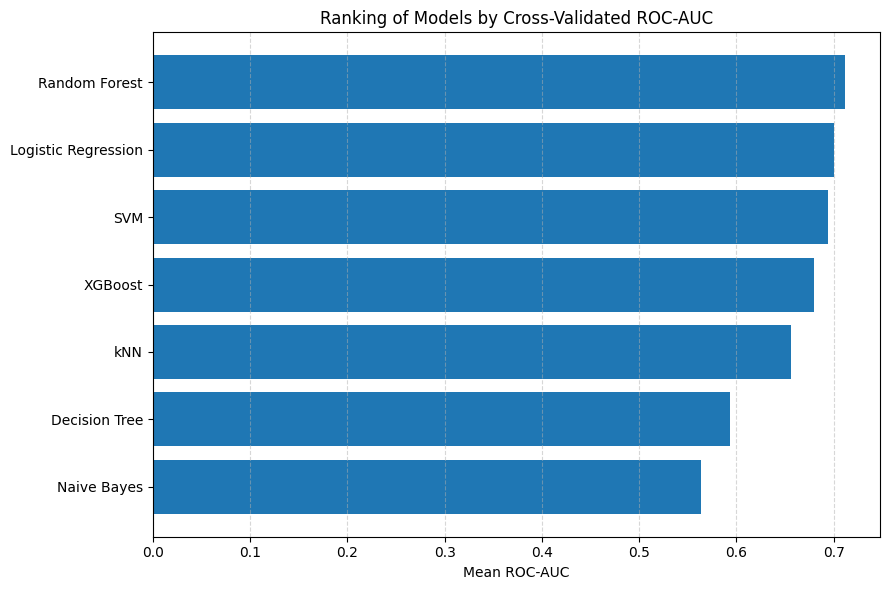

In [46]:
cv_results_df = cv_results_df.sort_values(
    "Mean_ROC_AUC",
    ascending=True
)
plt.figure(figsize=(9,6))
plt.barh(
    cv_results_df["Model"],
    cv_results_df["Mean_ROC_AUC"]
)
plt.xlabel("Mean ROC-AUC")
plt.title("Ranking of Models by Cross-Validated ROC-AUC")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

**Figure 12. PCA analysis: PCR-positive vs PCR-negative**

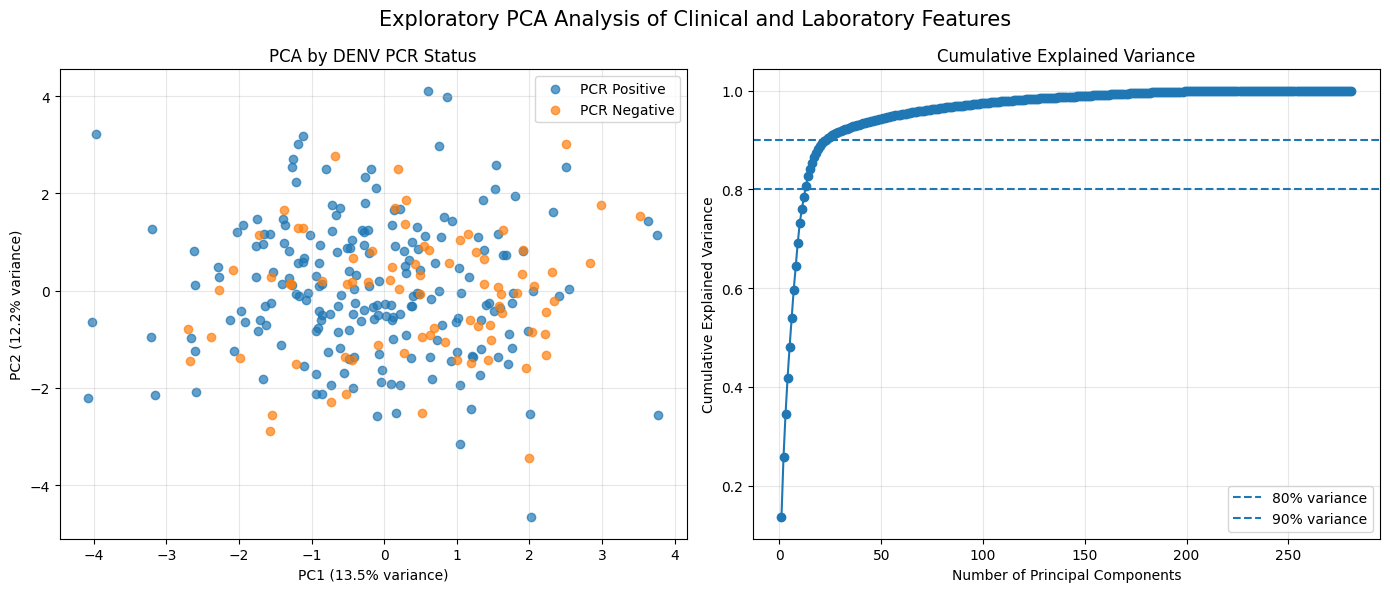

In [50]:
# Transform features using the existing preprocessor
X_processed = preprocessor.fit_transform(X_fixed)

# PCA for 2D visualization
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_processed)

# Full PCA for cumulative explained variance
pca_full = PCA()
pca_full.fit(X_processed)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Create PCA dataframe
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "PCR_status": y.map({
        0: "PCR Negative",
        1: "PCR Positive"
    })
})

# Create 1 x 2 figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: PCA scatter plot
for status in pca_df["PCR_status"].unique():
    subset = pca_df[pca_df["PCR_status"] == status]
    axes[0].scatter(
        subset["PC1"],
        subset["PC2"],
        label=status,
        alpha=0.7
    )

axes[0].set_xlabel(
    f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)"
)
axes[0].set_ylabel(
    f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)"
)
axes[0].set_title("PCA by DENV PCR Status")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Cumulative variance
axes[1].plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

axes[1].axhline(
    y=0.80,
    linestyle="--",
    label="80% variance"
)

axes[1].axhline(
    y=0.90,
    linestyle="--",
    label="90% variance"
)

axes[1].set_xlabel("Number of Principal Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Explained Variance")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(
    "Exploratory PCA Analysis of Clinical and Laboratory Features",
    fontsize=15
)

plt.tight_layout()
plt.show()

In [51]:
# PCA loading table
#This shows which variables contribute most to PC1 and PC2.

feature_names = preprocessor.get_feature_names_out()

loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=["PC1_loading", "PC2_loading"],
    index=feature_names
)

loadings_df["PC1_abs"] = loadings_df["PC1_loading"].abs()
loadings_df["PC2_abs"] = loadings_df["PC2_loading"].abs()

print("Top contributors to PC1:")
display(loadings_df.sort_values("PC1_abs", ascending=False).head(15))

print("Top contributors to PC2:")
display(loadings_df.sort_values("PC2_abs", ascending=False).head(15))

Top contributors to PC1:


,PC1_loading,PC2_loading,PC1_abs,PC2_abs
num__platelet_10_9_l,0.417317,-0.189154,0.417317,0.189154
num__year,0.405549,-0.084635,0.405549,0.084635
num__pulse,0.332429,-0.070313,0.332429,0.070313
num__respiratory_rate,0.314453,-0.146430,0.314453,0.146430
num__days_of_fever,-0.281191,0.160929,0.281191,0.160929
num__diastolic_blood_pressure,0.255168,0.556159,0.255168,0.556159
num__ast_iu_l,-0.224004,0.080539,0.224004,0.080539
num__hemotocrit,0.220755,0.333961,0.220755,0.333961
num__systolic_blood_pressure,0.214162,0.589645,0.214162,0.589645
num__age,-0.197491,0.332727,0.197491,0.332727


Top contributors to PC2:


,PC1_loading,PC2_loading,PC1_abs,PC2_abs
num__systolic_blood_pressure,0.214162,0.589645,0.214162,0.589645
num__diastolic_blood_pressure,0.255168,0.556159,0.255168,0.556159
num__hemotocrit,0.220755,0.333961,0.220755,0.333961
num__age,-0.197491,0.332727,0.197491,0.332727
num__platelet_10_9_l,0.417317,-0.189154,0.417317,0.189154
num__days_of_fever,-0.281191,0.160929,0.281191,0.160929
num__respiratory_rate,0.314453,-0.146430,0.314453,0.146430
num__year,0.405549,-0.084635,0.405549,0.084635
num__ast_iu_l,-0.224004,0.080539,0.224004,0.080539
num__pulse,0.332429,-0.070313,0.332429,0.070313


# Main biological interpretation

The PCA suggests that the major variation among patients is driven by:

1. Platelet count
2. Blood pressure
3. Hematocrit
4. Days of fever
5. AST
6. Age
7. Pulse and respiratory rate

So PCA supports the ML finding that the dataset contains a meaningful clinical/laboratory structure related to dengue-like illness.

However, PCA does not tell us which variables predict PCR positivity most strongly. It only tells us which variables explain the largest overall variation in the dataset.

For example:

* A variable can be important in PCA but not predictive of PCR status.
* A variable can be predictive of PCR status but not dominate PCA.
* PCA is unsupervised, so it does not know the PCR-positive/PCR-negative labels.

# **Thank you**


---


If you reached till here... You should celebrate